<a href="https://colab.research.google.com/github/kaynanxd/AvaliacaoDeDesempenho/blob/main/An%C3%A1lise_de_Desempenho_Exercicio_Complemetar_da_P1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Desempenho Exercicio Complemetar da P1
**Aluno:** kaynan santos freitas

## 0. Preparação do ambiente

In [41]:
!pip install line_solver --quiet

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from line_solver import (
    Network, Source, Queue, Sink, Delay, OpenClass, ClosedClass, Exp, SchedStrategy, SolverMVA,
    GlobalConstants, VerboseLevel,
)

GlobalConstants.set_verbose(VerboseLevel.SILENT)
pd.set_option('display.precision', 5)
plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['axes.grid'] = True

## 1. Exercícios 4.1, 4.2 e 4.3

### Revisão do problema motivador 1

Dados do enunciado:
- Taxa média de chegada de transações: $\lambda_0 = 30$ tps
- Tempo médio de processamento por transação: $S_0 = 20$ ms $\Rightarrow \mu_0 = 1/S_0 = 50$ transações/s

Trata-se de um sistema aberto com um único centro de serviço (CPU), modelado como uma fila
M/M/1. As métricas de desempenho pedidas são:
- Utilização do processador: $U = \lambda/\mu$
- Vazão do sistema (*throughput*): $X = \lambda$ (sistema estável)
- Tempo de resposta: $R = \dfrac{1}{\mu-\lambda}$
- Tamanho médio da fila (número médio no sistema): $N = \lambda R$ (Lei de Little)

Construi a seguir uma função que monta e resolve este modelo M/M/1 no LINE, usando o
solver analítico MVA (exato para M/M/1), para qualquer par $(\lambda,\mu)$.

In [43]:
def solve_mm1(lam, mu, label='CPU'):
    """Monta um modelo M/M/1 aberto no LINE e resolve com MVA.
    Retorna um dicionário com U, X (vazão), R (tempo de resposta) e N (nº médio no sistema).
    Se o sistema for instável (lam >= mu) retorna NaNs.
    """
    if lam <= 0 or mu <= 0 or lam >= mu:
        return {'lambda': lam, 'mu': mu, 'U': np.nan, 'X': np.nan, 'R': np.nan, 'N': np.nan}

    model = Network('MM1')
    source = Source(model, 'Source')
    queue = Queue(model, label, SchedStrategy.FCFS)
    sink = Sink(model, 'Sink')
    jobclass = OpenClass(model, 'Transacoes')
    source.set_arrival(jobclass, Exp(lam))
    queue.set_service(jobclass, Exp(mu))
    model.link(Network.serial_routing(source, queue, sink))

    avg = SolverMVA(model).avg_table()
    sub = avg.loc[avg['Station'] == label].copy().reset_index(drop=True)
    row = sub.iloc[0]
    U, X, R = float(row['Util']), float(row['Tput']), float(row['RespT'])
    N = X * R  # Lei de Little
    return {'lambda': lam, 'mu': mu, 'U': U, 'X': X, 'R': R, 'N': N}


# Caso base do problema motivador 1
lam0, mu0 = 30.0, 50.0
base = solve_mm1(lam0, mu0)
print("Caso base (problema motivador 1):")
for k, v in base.items():
    print(f"  {k} = {v:.5f}")

Caso base (problema motivador 1):
  lambda = 30.00000
  mu = 50.00000
  U = 0.60000
  X = 30.00000
  R = 0.05000
  N = 1.50000


O tempo de resposta obtido é $R_0 = 1/(\mu_0-\lambda_0) = 1/20 = 0{,}05\,s$, que é exatamente o
valor de referência citado no Exercício 4.2 (mantendo $R = 1/20$). A utilização é $U_0=0{,}6$
(60%), a vazão é igual à taxa de chegada ($X_0=30$ tps) e o número médio de transações no
sistema é $N_0 = 1{,}5$.

### 1.2 Exercício 4.1 Efeito da variação da carga de trabalho e da velocidade do processador

Vamos variar (a) a carga de trabalho $\lambda$ e (b) a velocidade do processador $\mu$ em
$-200\%,-100\%,-50\%,-10\%,+10\%,+50\%,+100\%,+200\%$ em relação aos valores originais, e
observar o efeito sobre $U$, $X$, $N$ e $R$.

In [44]:
deltas = np.array([-2.00, -1.00, -0.50, -0.10, 0.10, 0.50, 1.00, 2.00])

rows_a = [solve_mm1(lam0 * (1 + d), mu0) for d in deltas]
tab_a = pd.DataFrame(rows_a)
tab_a.insert(0, 'delta_%', (deltas * 100).astype(int))
print("(a) Variação da carga de trabalho (lambda), mu = mu0 = 50 tps fixo")
print(tab_a.to_string(index=False))

(a) Variação da carga de trabalho (lambda), mu = mu0 = 50 tps fixo
 delta_%  lambda   mu    U    X       R       N
    -200   -30.0 50.0  NaN  NaN     NaN     NaN
    -100     0.0 50.0  NaN  NaN     NaN     NaN
     -50    15.0 50.0 0.30 15.0 0.02857 0.42857
     -10    27.0 50.0 0.54 27.0 0.04348 1.17391
      10    33.0 50.0 0.66 33.0 0.05882 1.94118
      50    45.0 50.0 0.90 45.0 0.20000 9.00000
     100    60.0 50.0  NaN  NaN     NaN     NaN
     200    90.0 50.0  NaN  NaN     NaN     NaN


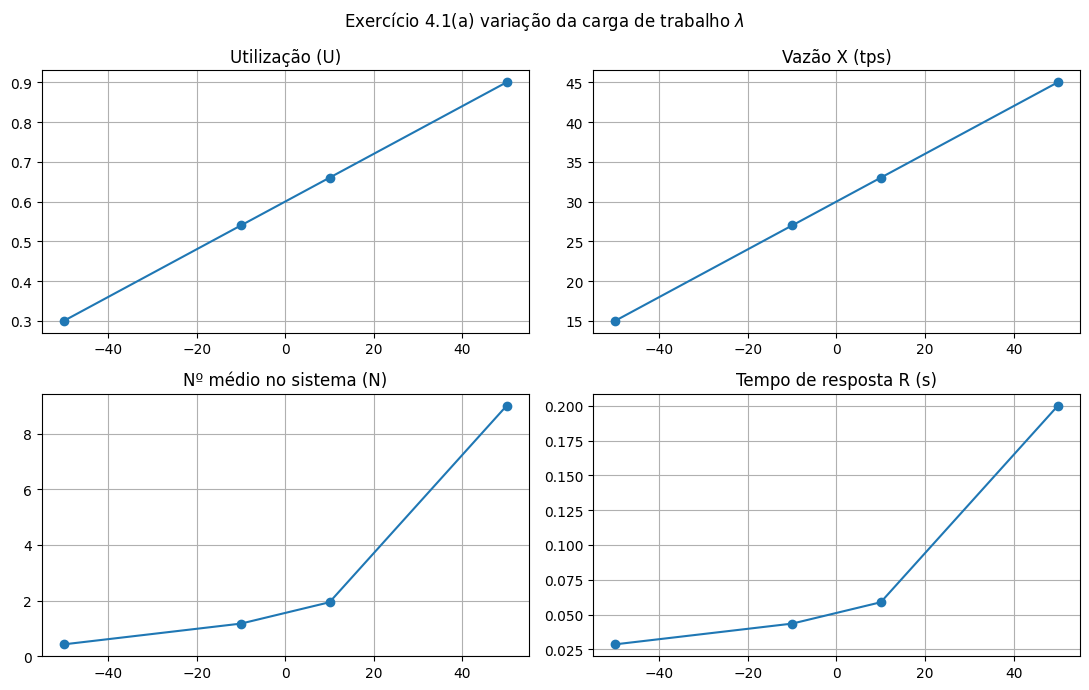

In [45]:
fig, axs = plt.subplots(2, 2, figsize=(11, 7))
for ax, col, ttl in zip(axs.flat, ['U', 'X', 'N', 'R'],
                         ['Utilização (U)', 'Vazão X (tps)',
                          'Nº médio no sistema (N)', 'Tempo de resposta R (s)']):
    ax.plot(tab_a['delta_%'], tab_a[col], 'o-', color='tab:blue')
    ax.set_title(ttl)
fig.suptitle('Exercício 4.1(a) variação da carga de trabalho $\\lambda$')
fig.tight_layout()
plt.show()

**Comentário (a):** para $\delta \le -100\%$ a taxa de chegada é nula ou negativa (sem sentido
físico) e por isso as métricas não são calculadas (`NaN`). Para $\delta = +100\%$ obtemos
$\lambda = 60 = \mu_0$: o sistema atinge $\rho=1$ e o tempo de resposta e o número em fila
tenderiam ao infinito (instabilidade); para $\delta=+200\%$ a carga ($\lambda=90$) supera a
capacidade do processador ($\mu_0=50$) e o sistema é instável — por isso essas colunas também
aparecem como `NaN`. Nos pontos estáveis observa-se o comportamento típico de fila M/M/1: $U$ e
$X$ crescem linearmente com $\lambda$, enquanto $N$ e $R$ crescem de forma não linear (e
explosiva) à medida que $\lambda$ se aproxima de $\mu_0$ — evidenciando o "joelho" característico
da curva de tempo de resposta em função da utilização.

In [46]:
rows_b = [solve_mm1(lam0, mu0 * (1 + d)) for d in deltas]
tab_b = pd.DataFrame(rows_b)
tab_b.insert(0, 'delta_%', (deltas * 100).astype(int))
print("(b) Variação da velocidade do processador (mu), lambda = lam0 = 30 tps fixo")
print(tab_b.to_string(index=False))

(b) Variação da velocidade do processador (mu), lambda = lam0 = 30 tps fixo
 delta_%  lambda    mu       U    X       R       N
    -200    30.0 -50.0     NaN  NaN     NaN     NaN
    -100    30.0   0.0     NaN  NaN     NaN     NaN
     -50    30.0  25.0     NaN  NaN     NaN     NaN
     -10    30.0  45.0 0.66667 30.0 0.06667 2.00000
      10    30.0  55.0 0.54545 30.0 0.04000 1.20000
      50    30.0  75.0 0.40000 30.0 0.02222 0.66667
     100    30.0 100.0 0.30000 30.0 0.01429 0.42857
     200    30.0 150.0 0.20000 30.0 0.00833 0.25000


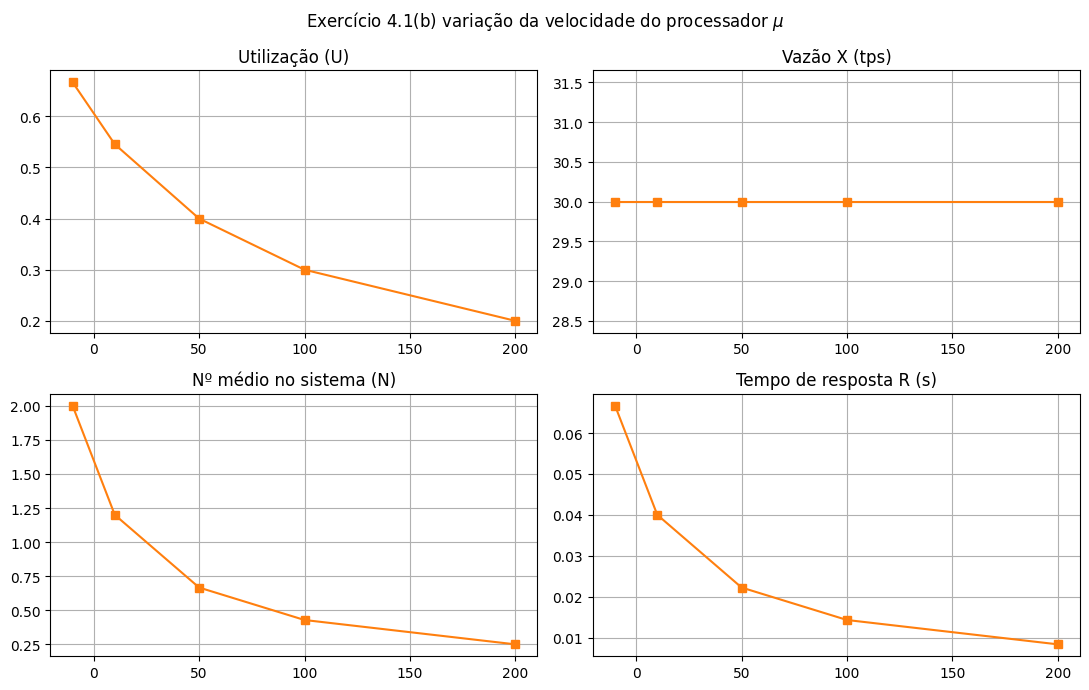

In [47]:
fig, axs = plt.subplots(2, 2, figsize=(11, 7))
for ax, col, ttl in zip(axs.flat, ['U', 'X', 'N', 'R'],
                         ['Utilização (U)', 'Vazão X (tps)',
                          'Nº médio no sistema (N)', 'Tempo de resposta R (s)']):
    ax.plot(tab_b['delta_%'], tab_b[col], 's-', color='tab:orange')
    ax.set_title(ttl)
fig.suptitle('Exercício 4.1(b) variação da velocidade do processador $\\mu$')
fig.tight_layout()
plt.show()

**Comentário (b):** reduções de 100% ou 200% tornam $\mu \le 0$ (sem sentido) e uma redução de
50% resulta em $\mu=25 < \lambda_0=30$, isto é, o processador se torna mais lento que a taxa de
chegada e o sistema também é instável. Nos pontos estáveis, quanto mais rápido o processador,
menor a utilização, menor a fila e menor o tempo de resposta — mas com retornos
decrescentes: dobrar a velocidade (+100%) reduz $R$ bem mais do que triplicá-la reduziria
ainda mais $R$ pela mesma proporção (a curva $R\times\mu$ é hiperbólica, não linear).

### 1.3 Exercício 4.2 Aceleração do processador necessária para manter $R=1/20$

Se a carga de trabalho aumentar $p\%$ (isto é, $\lambda' = \lambda_0(1+p)$), qual deve ser o
fator de aceleração do processador ($\mu'/\mu_0$) para manter o tempo de resposta original
$R_0 = 1/20$ s?

Para cada $p$, usamos o **LINE** (função `solve_mm1`) dentro de uma busca de raiz (`brentq`,
do SciPy) para encontrar $\mu'$ tal que $R(\lambda',\mu') = R_0$.

In [48]:
R0 = base['R']  # 0.05 = 1/20


def R_of_mu(mu, lam):
    return solve_mm1(lam, mu)['R']


def mu_for_target_R(lam, R_target, mu_lo=None, mu_hi=1e5):
    mu_lo = lam * 1.0000001 if mu_lo is None else mu_lo
    f = lambda mu: R_of_mu(mu, lam) - R_target
    return brentq(f, mu_lo, mu_hi)


p_values = np.array([-0.50, -0.25, -0.10, 0.0, 0.10, 0.25, 0.50, 1.00, 1.50, 2.00])
rows_2 = []
for p in p_values:
    lam_new = lam0 * (1 + p)
    mu_new = mu_for_target_R(lam_new, R0)
    speedup = mu_new / mu0 - 1
    rows_2.append({'p_%': p * 100, 'lambda_novo': lam_new, 'mu_novo': mu_new,
                    'aceleracao_%_LINE': speedup * 100,
                    'aceleracao_%_formula': 60 * p})
tab_2 = pd.DataFrame(rows_2)
print(tab_2.to_string(index=False))

  p_%  lambda_novo  mu_novo  aceleracao_%_LINE  aceleracao_%_formula
-50.0         15.0     35.0              -30.0                 -30.0
-25.0         22.5     42.5              -15.0                 -15.0
-10.0         27.0     47.0               -6.0                  -6.0
  0.0         30.0     50.0                0.0                   0.0
 10.0         33.0     53.0                6.0                   6.0
 25.0         37.5     57.5               15.0                  15.0
 50.0         45.0     65.0               30.0                  30.0
100.0         60.0     80.0               60.0                  60.0
150.0         75.0     95.0               90.0                  90.0
200.0         90.0    110.0              120.0                 120.0


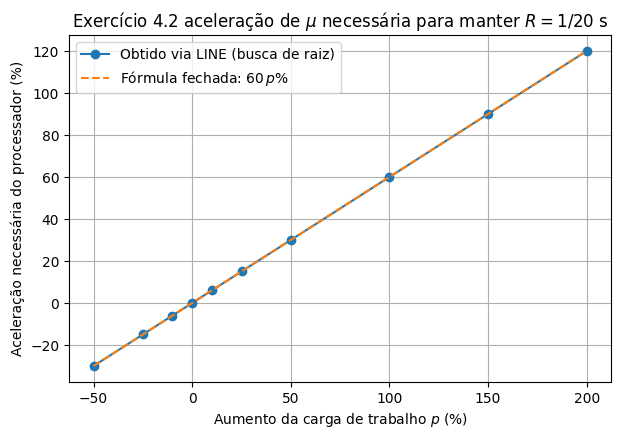

In [49]:
plt.plot(tab_2['p_%'], tab_2['aceleracao_%_LINE'], 'o-', label='Obtido via LINE (busca de raiz)')
plt.plot(tab_2['p_%'], tab_2['aceleracao_%_formula'], '--', label='Fórmula fechada: $60\\,p\\%$')
plt.xlabel('Aumento da carga de trabalho $p$ (%)')
plt.ylabel('Aceleração necessária do processador (%)')
plt.title('Exercício 4.2 aceleração de $\\mu$ necessária para manter $R=1/20$ s')
plt.legend()
plt.show()

**Comentário:** como $R_0=1/(\mu-\lambda)$ é fixo, temos $\mu' = \lambda' + 1/R_0 = 30(1+p) + 20$,
logo o fator de aceleração é $\mu'/\mu_0 - 1 = \dfrac{30(1+p)+20}{50}-1 = 0{,}6\,p$, ou seja,
60% de aceleração do processador para cada 100% de aumento na carga de trabalho, exatamente
o que a curva obtida numericamente pelo LINE reproduz (as duas curvas coincidem). Isso mostra
que, neste sistema, o processador precisa crescer proporcionalmente menos que a carga (fator
0,6), porque parte da margem "original" (a diferença $\mu_0-\lambda_0=20$) já é preservada pela
própria definição de $R_0$.

### 1.4 Exercício 4.3 Aumento de carga suportável mantendo $R=1/20$

Problema simétrico ao anterior: se o processador for acelerado em $q\%$
($\mu' = \mu_0(1+q)$), qual o aumento percentual de carga de trabalho que pode ser
acomodado mantendo $R=1/20$ s?

In [50]:
def lam_for_target_R(mu, R_target, lam_lo=1e-6, lam_hi=None):
    lam_hi = mu * 0.9999999 if lam_hi is None else lam_hi
    f = lambda lam: R_of_mu(mu, lam) - R_target
    return brentq(f, lam_lo, lam_hi)


q_values = np.array([-0.50, -0.25, -0.10, 0.0, 0.10, 0.25, 0.50, 1.00, 1.50, 2.00])
rows_3 = []
for q in q_values:
    mu_new = mu0 * (1 + q)
    lam_new = lam_for_target_R(mu_new, R0)
    workload_increase = lam_new / lam0 - 1
    rows_3.append({'q_%': q * 100, 'mu_novo': mu_new, 'lambda_novo': lam_new,
                    'aumento_carga_%_LINE': workload_increase * 100,
                    'aumento_carga_%_formula': (5 / 3) * q * 100})
tab_3 = pd.DataFrame(rows_3)
print(tab_3.to_string(index=False))

  q_%  mu_novo  lambda_novo  aumento_carga_%_LINE  aumento_carga_%_formula
-50.0     25.0          5.0          -8.33333e+01                -83.33333
-25.0     37.5         17.5          -4.16667e+01                -41.66667
-10.0     45.0         25.0          -1.66667e+01                -16.66667
  0.0     50.0         30.0          -2.22045e-14                  0.00000
 10.0     55.0         35.0           1.66667e+01                 16.66667
 25.0     62.5         42.5           4.16667e+01                 41.66667
 50.0     75.0         55.0           8.33333e+01                 83.33333
100.0    100.0         80.0           1.66667e+02                166.66667
150.0    125.0        105.0           2.50000e+02                250.00000
200.0    150.0        130.0           3.33333e+02                333.33333


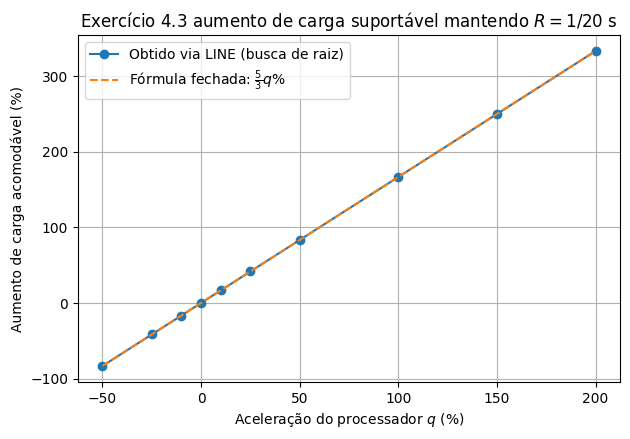

In [51]:
plt.plot(tab_3['q_%'], tab_3['aumento_carga_%_LINE'], 'o-', label='Obtido via LINE (busca de raiz)')
plt.plot(tab_3['q_%'], tab_3['aumento_carga_%_formula'], '--', label='Fórmula fechada: $\\frac{5}{3}q\\%$')
plt.xlabel('Aceleração do processador $q$ (%)')
plt.ylabel('Aumento de carga acomodável (%)')
plt.title('Exercício 4.3 aumento de carga suportável mantendo $R=1/20$ s')
plt.legend()
plt.show()

**Comentário:** de forma simétrica, $\lambda' = \mu'-1/R_0 = 50(1+q)-20$, logo o aumento
percentual de carga é $\lambda'/\lambda_0 - 1 = \dfrac{50(1+q)-20}{30}-1 = \dfrac{5}{3}q$, isto
é, cada 1% de aceleração do processador permite absorver aproximadamente 1,67% de aumento na
carga de trabalho, o inverso do fator 0,6 do exercício anterior ($1/0{,}6=1{,}67$), como
esperado, já que os dois exercícios resolvem a mesma equação de restrição em direções opostas.

## 2. Questão 3.12 Modelo de 3 classe

### 2.1 O modelo

A Seção 3.5 descreve um sistema com 3 dispositivos (CPU, Disco 1, Disco 2) atendendo
simultaneamente 3 classes de carga de trabalho, cada uma caracterizada de forma diferente:

- Transação classe aberta: chegada de Poisson com taxa
  $\lambda = 0{,}05$ tps .
- Interativa classe fechada do tipo terminal: 20 terminais, tempo
  médio de *think* $Z=30$ s . É representada por um centro de atraso
  que modela o tempo que o usuário fica "pensando" entre uma resposta e a próxima submissão.
- Batch classe fechada do tipo lote (sem terminais/think time): população
  média fixa $\overline{N}=1{,}50$ jobs em execução simultânea (Tabela 3.16), circulando
  continuamente pelos dispositivos.

As demandas de serviço $D_{i,r}$ (em segundos), i.e., o tempo total gasto por transação da
classe $r$ no dispositivo $i$, vêm da Tabela 3.6:

| Dispositivo | Transação | Interativa | Batch |
|---|---|---|---|
| CPU    | 0,80 | 0,30 | 5,00 |
| Disco 1| 0,75 | 0,45 | 0,55 |
| Disco 2| 0,25 | 0,30 | 0,60 |



In [52]:
D_312 = {
    'CPU':    {'Transacao': 0.80, 'Interativa': 0.30, 'Batch': 5.00},
    'Disco1': {'Transacao': 0.75, 'Interativa': 0.45, 'Batch': 0.55},
    'Disco2': {'Transacao': 0.25, 'Interativa': 0.30, 'Batch': 0.60},
}
N_interativa, Z_interativa = 20, 30.0
N_batch = 1.50
lam_transacao_orig = 0.05


def build_and_solve_312(lam_trans=lam_transacao_orig, mu_scale=None,
                         cpu_servers=1, disk1_servers=1, disk2_servers=1,
                         D=D_312, N_int=N_interativa, Z_int=Z_interativa, N_bat=N_batch):
    """Monta a rede mista de 3 classes no LINE e resolve com MVA."""
    mu_scale = mu_scale or {}
    model = Network('Modelo3Classes')
    source = Source(model, 'Source')
    sink = Sink(model, 'Sink')
    cpu = Queue(model, 'CPU', SchedStrategy.FCFS)
    cpu.set_number_of_servers(cpu_servers)
    disk1 = Queue(model, 'Disco1', SchedStrategy.FCFS)
    disk1.set_number_of_servers(disk1_servers)
    disk2 = Queue(model, 'Disco2', SchedStrategy.FCFS)
    disk2.set_number_of_servers(disk2_servers)
    delay = Delay(model, 'Terminais')

    transacao = OpenClass(model, 'Transacao')
    source.set_arrival(transacao, Exp(lam_trans))

    interativa = ClosedClass(model, 'Interativa', N_int, delay)
    delay.set_service(interativa, Exp(1.0 / Z_int))

    batch = ClosedClass(model, 'Batch', N_bat, cpu)

    for dev, node in [('CPU', cpu), ('Disco1', disk1), ('Disco2', disk2)]:
        scale = mu_scale.get(dev, 1.0)
        node.set_service(transacao, Exp(1.0 / (D[dev]['Transacao'] / scale)))
        node.set_service(interativa, Exp(1.0 / (D[dev]['Interativa'] / scale)))
        node.set_service(batch, Exp(1.0 / (D[dev]['Batch'] / scale)))

    P = model.init_routing_matrix()
    P.set(transacao, Network.serial_routing(source, cpu, disk1, disk2, sink))
    P.set(interativa, Network.serial_routing(delay, cpu, disk1, disk2, delay))
    P.set(batch, Network.serial_routing(cpu, disk1, disk2, cpu))
    model.link(P)

    return SolverMVA(model).avg_table()

In [53]:
# Cenário original (lambda_Transacao = 0,05 tps)
avg0_312 = build_and_solve_312()
print(f"Cenário original (lambda_Transacao = {lam_transacao_orig} tps):")
print(avg0_312.to_string(index=False))

U_cpu_orig = avg0_312.loc[avg0_312['Station'] == 'CPU', 'Util'].sum()
U_d1_orig = avg0_312.loc[avg0_312['Station'] == 'Disco1', 'Util'].sum()
U_d2_orig = avg0_312.loc[avg0_312['Station'] == 'Disco2', 'Util'].sum()
print(f"\nUtilização total por dispositivo — CPU: {U_cpu_orig:.4f}  "
      f"Disco1: {U_d1_orig:.4f}  Disco2: {U_d2_orig:.4f}")

Cenário original (lambda_Transacao = 0.05 tps):
Station    JobClass        QLen      Util    RespT   ResidT     ArvR     Tput
Source     Transacao          0         0        0        0        0     0.05
CPU        Transacao    0.44216      0.04   8.8432   8.8432     0.05     0.05
CPU        Interativa    4.2021   0.15225   8.2802   8.2802  0.50749  0.50749
CPU        Batch         1.2858   0.73411   8.7573   8.7573  0.14682  0.14682
Disco1     Transacao   0.050519    0.0375   1.0104   1.0104     0.05     0.05
Disco1     Interativa   0.35644   0.22837  0.70237  0.70237  0.50749  0.50749
Disco1     Batch        0.11291  0.080753  0.76899  0.76899  0.14682  0.14682
Disco2     Transacao   0.019031    0.0125  0.38061  0.38061     0.05     0.05
Disco2     Interativa   0.21688   0.15225  0.42736  0.42736  0.50749  0.50749
Disco2     Batch        0.10132  0.088094  0.69009  0.69009  0.14682  0.14682
Terminais  Interativa    15.225    15.225       30       30  0.50749  0.50749

Utilização tota

**Comentário:** somando a utilização das três classes em cada dispositivo, a CPU já está
ocupada ≈93% do tempo no cenário original, muito mais carregada que os discos (Disco 1
≈35%, Disco 2 ≈25%). A CPU é claramente o gargalo do sistema, o que já antecipa o
resultado da próxima seção: qualquer aumento de carga tende a impactar fortemente o tempo de
resposta, e upgrades que não envolvam a CPU terão pouco efeito.

### 2.2 Efeito do aumento da taxa de chegada da Transação para 0,4 tps

Mantendo fixos os parâmetros da Interativa (20 terminais, $Z=30$ s) e do Batch
($\overline{N}=1{,}5$), variamos apenas $\lambda_{Transacao}$ do valor original (0,05 tps)
até 0,4 tps, e observamos o tempo de resposta de cada classe.

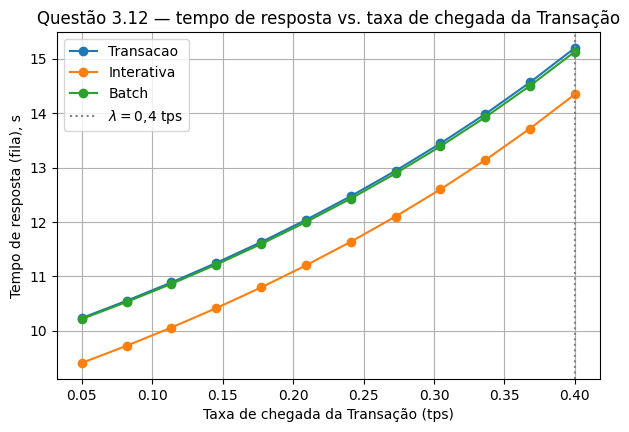

R (Transação) na taxa original (0,05 tps): 10.2342 s
R (Transação) em lambda = 0,4 tps:          15.1954 s
Variação: 48.5 %


In [54]:
lam_range_312 = np.linspace(lam_transacao_orig, 0.4, 12)
records_312 = []
for lam in lam_range_312:
    avg = build_and_solve_312(lam_trans=lam)
    for k in ['Transacao', 'Interativa', 'Batch']:
        sub_k = avg.loc[avg['JobClass'] == k].copy()
        if k == 'Interativa':
            R_fila = float(sub_k.loc[sub_k['Station'] != 'Terminais', 'RespT'].sum())
        else:
            R_fila = float(sub_k['RespT'].sum())
        records_312.append({'lambda_transacao': lam, 'classe': k, 'R_fila': R_fila})
tab_312 = pd.DataFrame(records_312)

plt.figure()
for k in ['Transacao', 'Interativa', 'Batch']:
    sub = tab_312[tab_312['classe'] == k]
    plt.plot(sub['lambda_transacao'], sub['R_fila'], 'o-', label=k)
plt.axvline(0.4, color='gray', linestyle=':', label='$\\lambda=0{,}4$ tps')
plt.xlabel('Taxa de chegada da Transação (tps)')
plt.ylabel('Tempo de resposta (fila), s')
plt.title('Questão 3.12 — tempo de resposta vs. taxa de chegada da Transação')
plt.legend()
plt.show()

R0_312 = tab_312.loc[(tab_312['lambda_transacao'] == lam_transacao_orig) &
                      (tab_312['classe'] == 'Transacao'), 'R_fila'].iloc[0]
R04_312 = tab_312.loc[(np.isclose(tab_312['lambda_transacao'], 0.4)) &
                       (tab_312['classe'] == 'Transacao'), 'R_fila'].iloc[0]
print(f"R (Transação) na taxa original (0,05 tps): {R0_312:.4f} s")
print(f"R (Transação) em lambda = 0,4 tps:          {R04_312:.4f} s")
print(f"Variação: {100*(R04_312/R0_312 - 1):.1f} %")

**Comentário:** o tempo de resposta da Transação sobe de ≈10,23 s para ≈15,20 s
(aumento de ≈48%) quando sua taxa de chegada vai de 0,05 para 0,4 tps, muito acima da
meta de no máximo 10% de degradação pedida no enunciado. As classes Interativa e Batch também
sofrem um pequeno aumento no tempo de resposta de fila, pois competem pelos mesmos
dispositivos (principalmente a CPU) com a Transação, que agora chega com mais frequência.

### 2.3 Alternativas para manter $R_{Transacao}$ a no máximo 10% acima do valor original em
$\lambda=0,4$ tps

Como identificado na Seção 2.1, a CPU é o gargalo (utilização ≈93% no cenário original).
Testamos abaixo, com o LINE, algumas alternativas isoladas e combinadas: acelerar a CPU,
acelerar os discos, e/ou replicar um dispositivo (mais de um servidor/unidade).

In [55]:
target_R_312 = 1.10 * R0_312
print(f"Tempo de resposta original da Transação: {R0_312:.4f} s")
print(f"Meta em lambda=0,4 tps (até 10% acima do original): {target_R_312:.4f} s\n")

scenarios_312 = {
    'Baseline (sem upgrade)':          dict(),
    'CPU 50% mais rápida':             dict(mu_scale={'CPU': 1.5}),
    'CPU 2x mais rápida':              dict(mu_scale={'CPU': 2.0}),
    'CPU com 2 servidores':            dict(cpu_servers=2),
    'Disco1 2x mais rápido':           dict(mu_scale={'Disco1': 2.0}),
    'Disco2 2x mais rápido':           dict(mu_scale={'Disco2': 2.0}),
    'Discos 1 e 2, 2x mais rápidos':   dict(mu_scale={'Disco1': 2.0, 'Disco2': 2.0}),
    'CPU 50% + Disco1 2x':             dict(mu_scale={'CPU': 1.5, 'Disco1': 2.0}),
}

rows_scn_312 = []
for name, cfg in scenarios_312.items():
    avg = build_and_solve_312(lam_trans=0.4, **cfg)
    R_t = avg.loc[avg['JobClass'] == 'Transacao', 'RespT'].sum()
    rows_scn_312.append({'cenario': name, 'R_Transacao_em_0.4tps': R_t,
                          'variacao_%_vs_original': 100 * (R_t / R0_312 - 1),
                          'dentro_da_meta_(<=10%)': R_t <= target_R_312})
tab_scn_312 = pd.DataFrame(rows_scn_312)
print(tab_scn_312.to_string(index=False))

Tempo de resposta original da Transação: 10.2342 s
Meta em lambda=0,4 tps (até 10% acima do original): 11.2577 s

                      cenario  R_Transacao_em_0.4tps  variacao_%_vs_original  dentro_da_meta_(<=10%)
       Baseline (sem upgrade)               15.19542                48.47649                   False
          CPU 50% mais rápida                8.41867               -17.74005                    True
           CPU 2x mais rápida                6.10102               -40.38615                    True
         CPU com 2 servidores                4.55677               -55.47523                    True
        Disco1 2x mais rápido               14.95637                46.14068                   False
        Disco2 2x mais rápido               15.29105                49.41089                   False
Discos 1 e 2, 2x mais rápidos               15.06840                47.23537                   False
          CPU 50% + Disco1 2x                8.00855               -21.74739  

In [56]:
def R_transacao(cpu_factor):
    avg = build_and_solve_312(lam_trans=0.4, mu_scale={'CPU': cpu_factor})
    return avg.loc[avg['JobClass'] == 'Transacao', 'RespT'].sum()


fator_cpu_min = brentq(lambda f: R_transacao(f) - target_R_312, 1.0001, 3.0)
print(f"\nAceleração mínima da CPU (isolada) para atingir a meta: "
      f"fator = {fator_cpu_min:.3f}x  (+{100*(fator_cpu_min-1):.1f}% de velocidade)")


Aceleração mínima da CPU (isolada) para atingir a meta: fator = 1.212x  (+21.2% de velocidade)


**Comentário:** como a CPU é o dispositivo mais carregado, acelerar apenas os discos não
resolve o problema (o tempo de resposta continua muito acima da meta,  a CPU continua
sendo o gargalo e absorve quase todo o aumento de carga. Já acelerar a CPU em apenas ≈21%
(ou, de forma equivalente, adicionar um segundo servidor de CPU) já é suficiente para trazer o
tempo de resposta da Transação para dentro da margem de 10% em relação ao valor original, mesmo
com $\lambda=0{,}4$ tps. Combinações de CPU mais rápida com discos mais rápidos atingem a meta
com ainda mais folga, mas o ganho marginal do disco é pequeno comparado ao da CPU — reforçando
que, neste sistema, o investimento mais eficiente é no gargalo (CPU), e não nos discos.